In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import os, pickle, copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
# ── All hyperparameters in one place ──────────────────────────
DATA_DIR    = r"D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset"
CACHE_FILE  = r"D:\dcgan\data\covid_xray\covid_cache.pkl"

IMG_SIZE    = 224        # ResNet18 native size
BATCH_SIZE  = 64
CNN_EPOCHS  = 10
GAN_EPOCHS  = 100
LR_CNN      = 1e-3
LR_GAN      = 2e-4
LATENT_DIM  = 100
N_SYNTHETIC = 1000       # synthetic images per weak class

CLASS_NAMES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# Folder names exactly as they appear in the dataset
FOLDER_NAMES = {
    'COVID'            : 'COVID',
    'Lung_Opacity'     : 'Lung_Opacity',
    'Normal'           : 'Normal',
    'Viral Pneumonia'  : 'Viral Pneumonia',
}

In [5]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # X-rays are grayscale → 3ch for ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

if os.path.exists(CACHE_FILE):
    print("Loading from cache...")
    with open(CACHE_FILE, 'rb') as f:
        all_images, all_labels = pickle.load(f)
    print(f"Loaded {len(all_images)} images.")
else:
    print("Building cache — runs once (~5 mins)...")
    all_images, all_labels = [], []
    for cls_name, folder in FOLDER_NAMES.items():
        img_dir = os.path.join(DATA_DIR, folder, 'images')
        files   = [f for f in os.listdir(img_dir) if f.endswith('.png')]
        label   = CLASS_TO_IDX[cls_name]
        for idx, fname in enumerate(files):
            if idx % 500 == 0:
                print(f"  {cls_name}: {idx}/{len(files)}")
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            all_images.append(transform(img))
            all_labels.append(label)
    all_images = torch.stack(all_images)
    all_labels = torch.tensor(all_labels)
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump((all_images, all_labels), f)
    print("Cache saved!")

# Train / test split — 80/20 stratified
from sklearn.model_selection import train_test_split
indices = list(range(len(all_labels)))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42,
    stratify=all_labels.numpy()
)
train_images = all_images[train_idx]
train_labels = all_labels[train_idx]
test_images  = all_images[test_idx]
test_labels  = all_labels[test_idx]

trainset    = TensorDataset(train_images, train_labels)
testset     = TensorDataset(test_images,  test_labels)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain: {len(trainset)} | Test: {len(testset)}")
print("\nClass distribution (train):")
for i, cls in enumerate(CLASS_NAMES):
    count = (train_labels == i).sum().item()
    print(f"  {cls:20s}: {count}")

Building cache — runs once (~5 mins)...
  COVID: 0/3616
  COVID: 500/3616
  COVID: 1000/3616
  COVID: 1500/3616
  COVID: 2000/3616
  COVID: 2500/3616
  COVID: 3000/3616
  COVID: 3500/3616
  Lung_Opacity: 0/6012
  Lung_Opacity: 500/6012
  Lung_Opacity: 1000/6012
  Lung_Opacity: 1500/6012
  Lung_Opacity: 2000/6012
  Lung_Opacity: 2500/6012
  Lung_Opacity: 3000/6012
  Lung_Opacity: 3500/6012
  Lung_Opacity: 4000/6012
  Lung_Opacity: 4500/6012
  Lung_Opacity: 5000/6012
  Lung_Opacity: 5500/6012
  Lung_Opacity: 6000/6012
  Normal: 0/10192
  Normal: 500/10192
  Normal: 1000/10192
  Normal: 1500/10192
  Normal: 2000/10192
  Normal: 2500/10192
  Normal: 3000/10192
  Normal: 3500/10192
  Normal: 4000/10192
  Normal: 4500/10192
  Normal: 5000/10192
  Normal: 5500/10192
  Normal: 6000/10192
  Normal: 6500/10192
  Normal: 7000/10192
  Normal: 7500/10192
  Normal: 8000/10192
  Normal: 8500/10192
  Normal: 9000/10192
  Normal: 9500/10192
  Normal: 10000/10192
  Viral Pneumonia: 0/1345
  Viral Pneumo

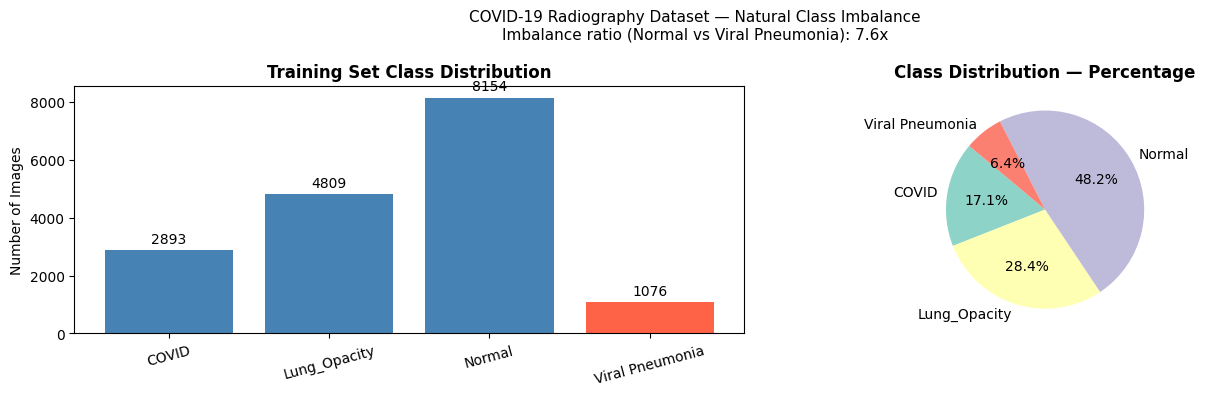

In [6]:
counts = [(train_labels == i).sum().item() for i in range(4)]
colors = ['tomato' if c == min(counts) else 'steelblue' for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(CLASS_NAMES, counts, color=colors)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Training Set Class Distribution", fontweight='bold')
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(counts, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=plt.cm.Set3.colors[:4], startangle=140)
axes[1].set_title("Class Distribution — Percentage", fontweight='bold')

plt.suptitle(f"COVID-19 Radiography Dataset — Natural Class Imbalance\n"
             f"Imbalance ratio (Normal vs Viral Pneumonia): "
             f"{max(counts)/min(counts):.1f}x", fontsize=11)
plt.tight_layout()
plt.show()

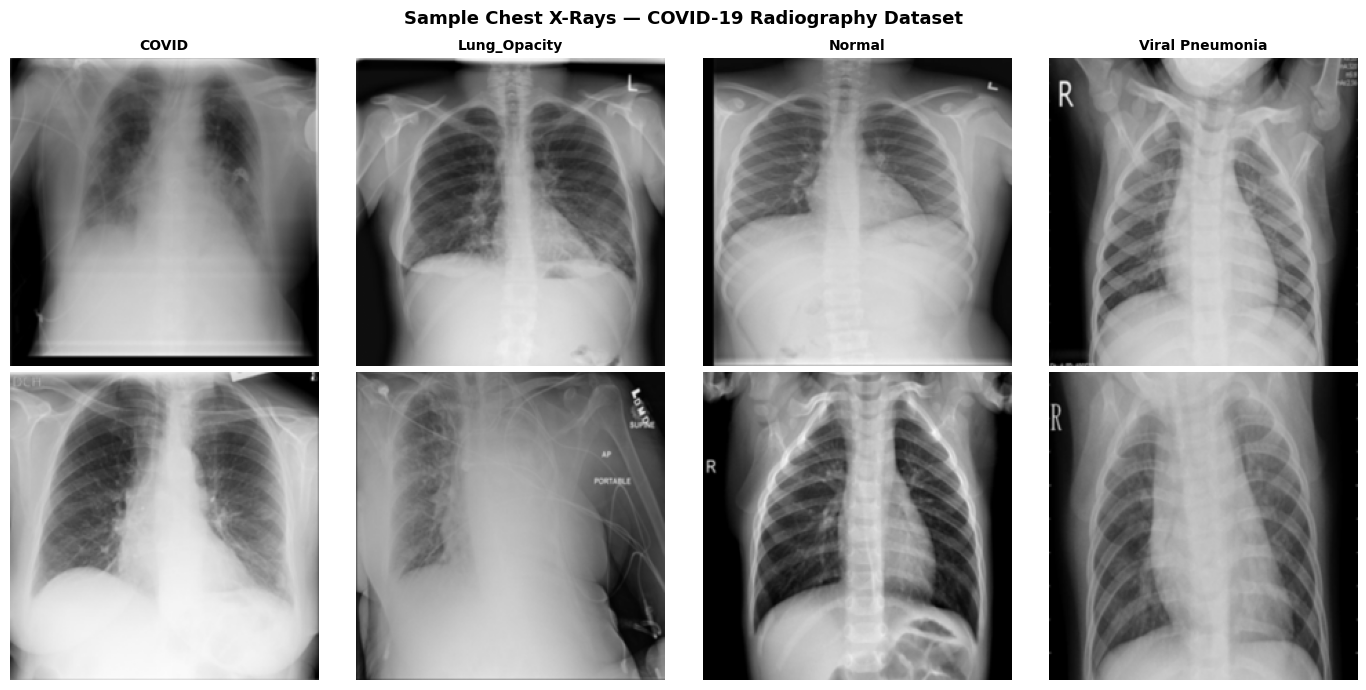

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, cls in enumerate(CLASS_NAMES):
    # show 2 real samples per class
    idx_list = (train_labels == CLASS_TO_IDX[cls]).nonzero(as_tuple=True)[0][:2]
    for row in range(2):
        img = train_images[idx_list[row]].permute(1,2,0).numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls, fontsize=10, fontweight='bold')

plt.suptitle("Sample Chest X-Rays — COVID-19 Radiography Dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Freeze backbone — only FC head is trainable
        for param in resnet.parameters():
            param.requires_grad = False
        resnet.fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        self.model = resnet

    def forward(self, x):
        return self.model(x)

print("ResNetClassifier defined.")
print(f"Trainable params: "
      f"{sum(p.numel() for p in ResNetClassifier().parameters() if p.requires_grad):,}")

ResNetClassifier defined.
Trainable params: 132,356


In [9]:
def get_class_weights(labels):
    counts  = torch.bincount(labels, minlength=4).float()
    weights = counts.sum() / (4 * counts)
    return weights

def train_cnn(model, loader, epochs, lr, weighted=True):
    model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    if weighted:
        w = get_class_weights(loader.dataset.tensors[1]).to(device)
        criterion = nn.CrossEntropyLoss(weight=w)
        print("Using weighted CrossEntropyLoss")
    else:
        criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
        print(f"Epoch {epoch+1}/{epochs} — "
              f"Loss: {total_loss/len(loader):.3f} | "
              f"Acc: {100*correct/total:.1f}%")
    return model

def evaluate_per_class(model, loader):
    model.eval()
    correct = Counter()
    total   = Counter()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            for p, l in zip(preds, labels):
                total[l.item()]   += 1
                if p == l:
                    correct[l.item()] += 1
    return {i: 100 * correct[i] / total[i] for i in range(4)}

In [10]:
baseline_model = ResNetClassifier(num_classes=4)
print("Training Baseline ResNet18 on imbalanced data...\n")
baseline_model = train_cnn(baseline_model, trainloader,
                           CNN_EPOCHS, LR_CNN, weighted=True)

baseline_acc = evaluate_per_class(baseline_model, testloader)

print("\nPer-Class Accuracy (Baseline):")
print("-" * 50)
for i, cls in enumerate(CLASS_NAMES):
    acc = baseline_acc[i]
    bar = '█' * int(acc // 5)
    print(f"  {cls:20s}: {acc:5.1f}%  {bar}")
print("-" * 50)
print(f"  {'Overall':20s}: {np.mean(list(baseline_acc.values())):.1f}%")

# Identify weak class automatically
WEAK_CLASS = min(baseline_acc, key=baseline_acc.get)
print(f"\nWeak class identified: '{CLASS_NAMES[WEAK_CLASS]}' "
      f"({baseline_acc[WEAK_CLASS]:.1f}%) ← will be augmented by DCGAN")

Training Baseline ResNet18 on imbalanced data...

Using weighted CrossEntropyLoss
Epoch 1/10 — Loss: 0.604 | Acc: 72.8%
Epoch 2/10 — Loss: 0.433 | Acc: 80.1%
Epoch 3/10 — Loss: 0.393 | Acc: 81.8%
Epoch 4/10 — Loss: 0.369 | Acc: 82.7%
Epoch 5/10 — Loss: 0.345 | Acc: 83.6%
Epoch 6/10 — Loss: 0.339 | Acc: 83.9%
Epoch 7/10 — Loss: 0.319 | Acc: 84.9%
Epoch 8/10 — Loss: 0.313 | Acc: 85.2%
Epoch 9/10 — Loss: 0.300 | Acc: 85.8%
Epoch 10/10 — Loss: 0.298 | Acc: 85.9%

Per-Class Accuracy (Baseline):
--------------------------------------------------
  COVID               :  90.3%  ██████████████████
  Lung_Opacity        :  83.5%  ████████████████
  Normal              :  83.1%  ████████████████
  Viral Pneumonia     :  96.7%  ███████████████████
--------------------------------------------------
  Overall             : 88.4%

Weak class identified: 'Normal' (83.1%) ← will be augmented by DCGAN


In [11]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),   # 4x4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),   # 8x8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),   # 16x16
            nn.ConvTranspose2d(128, 64,  4, 2, 1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(True),   # 32x32
            nn.ConvTranspose2d(64,  3,   4, 2, 1, bias=False),
            nn.Tanh()                              # 64x64
        )
    def forward(self, x): return self.net(x)

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64,  4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),                        # 32x32
            nn.Conv2d(64,  128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),  # 16x16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),  # 8x8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),  # 4x4
            nn.Conv2d(512, 1,   4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).view(-1)

In [13]:
# Note: GAN trains on 64x64 images (resized from 224x224 train tensors)
# We downsample only for GAN training — classifier always uses 224x224

gan_resize = transforms.Resize((64, 64), antialias=True)

def train_dcgan(train_images, train_labels, target_class, epochs):
    mask        = (train_labels == target_class)
    weak_imgs   = torch.stack([gan_resize(img) for img in train_images[mask]])
    weak_ds     = TensorDataset(weak_imgs, train_labels[mask])
    weak_loader = DataLoader(weak_ds, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=0)

    print(f"Training DCGAN on '{CLASS_NAMES[target_class]}' "
          f"({len(weak_imgs)} images)...")

    G = Generator().to(device)
    D = Discriminator().to(device)
    opt_G     = optim.Adam(G.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
    opt_D     = optim.Adam(D.parameters(), lr=LR_GAN * 0.5, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(weak_loader):
            imgs        = imgs.to(device)
            b           = imgs.size(0)
            real_labels = torch.ones(b).to(device)  * 0.9
            fake_labels = torch.zeros(b).to(device)

            if i % 2 == 0:
                opt_D.zero_grad()
                loss_real = criterion(D(imgs), real_labels)
                noise     = torch.randn(b, LATENT_DIM, 1, 1).to(device)
                loss_fake = criterion(D(G(noise).detach()), fake_labels)
                (loss_real + loss_fake).backward()
                opt_D.step()

            opt_G.zero_grad()
            noise  = torch.randn(b, LATENT_DIM, 1, 1).to(device)
            loss_G = criterion(D(G(noise)), real_labels)
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1}/{epochs} — "
                  f"D_loss: {(loss_real+loss_fake).item():.3f} | "
                  f"G_loss: {loss_G.item():.3f}")
    return G

generator = train_dcgan(train_images, train_labels, WEAK_CLASS, GAN_EPOCHS)
print("\nDCGAN training complete.")

Training DCGAN on 'Normal' (8154 images)...
  Epoch 25/100 — D_loss: 1.221 | G_loss: 1.042
  Epoch 50/100 — D_loss: 1.500 | G_loss: 1.121
  Epoch 75/100 — D_loss: 0.866 | G_loss: 1.613
  Epoch 100/100 — D_loss: 0.860 | G_loss: 1.890

DCGAN training complete.


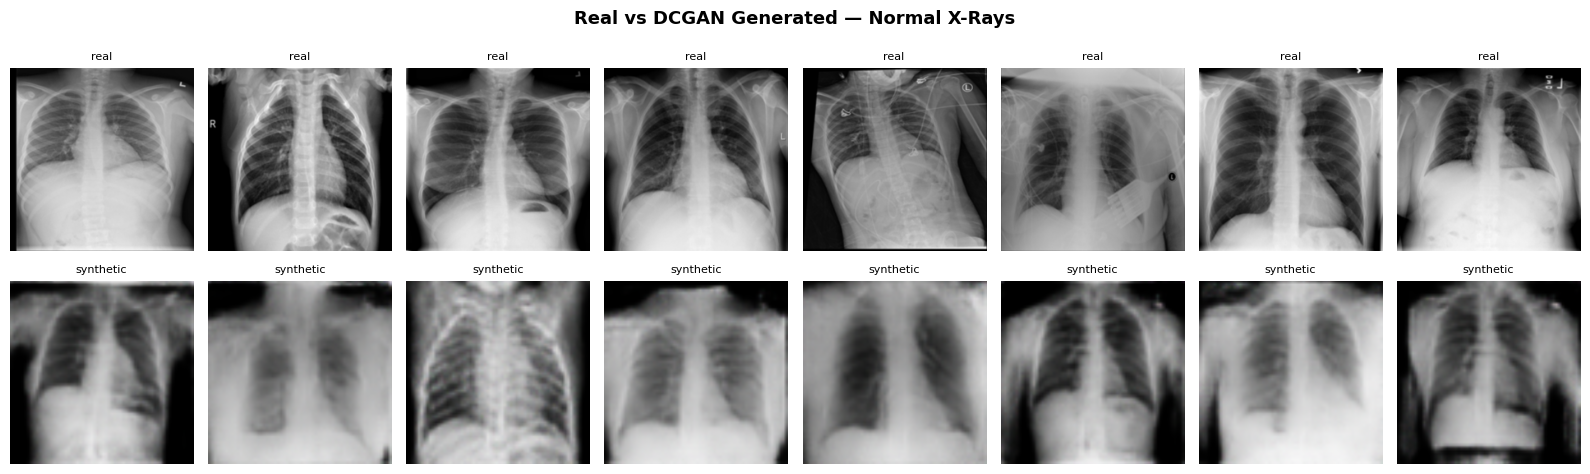

Generated 1000 synthetic images


In [14]:
upsample = transforms.Resize((224, 224), antialias=True)

def generate_synthetic(generator, n, target_class):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n, LATENT_DIM, 1, 1).to(device)
        imgs  = generator(noise).cpu()
    # Upsample from 64x64 → 224x224 to match classifier input
    imgs = torch.stack([upsample(img) for img in imgs])
    labels = torch.full((n,), target_class, dtype=torch.long)
    return imgs, labels

syn_images, syn_labels = generate_synthetic(generator, N_SYNTHETIC, WEAK_CLASS)

# Real vs Synthetic comparison
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
real_idx  = (train_labels == WEAK_CLASS).nonzero(as_tuple=True)[0][:8]

for col in range(8):
    # Real
    img = train_images[real_idx[col]].permute(1,2,0).numpy()
    axes[0][col].imshow((img*0.5+0.5).clip(0,1), cmap='gray')
    axes[0][col].set_title(f"real", fontsize=8)
    axes[0][col].axis('off')
    # Fake
    img = syn_images[col].permute(1,2,0).numpy()
    axes[1][col].imshow((img*0.5+0.5).clip(0,1), cmap='gray')
    axes[1][col].set_title(f"synthetic", fontsize=8)
    axes[1][col].axis('off')

plt.suptitle(f"Real vs DCGAN Generated — {CLASS_NAMES[WEAK_CLASS]} X-Rays",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Generated {len(syn_images)} synthetic images")

In [15]:
expanded_ds     = TensorDataset(
    torch.cat([train_images, syn_images]),
    torch.cat([train_labels, syn_labels])
)
expanded_loader = DataLoader(expanded_ds, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=0)

retrained_model = copy.deepcopy(baseline_model)

print(f"Dataset sizes:")
print(f"  Original : {len(train_images)}")
print(f"  Synthetic: {len(syn_images)}")
print(f"  Total    : {len(expanded_ds)}")
print(f"\nFine-tuning FC head on expanded dataset...\n")

retrained_model = train_cnn(retrained_model, expanded_loader,
                            epochs=8, lr=5e-4, weighted=True)

Dataset sizes:
  Original : 16932
  Synthetic: 1000
  Total    : 17932

Fine-tuning FC head on expanded dataset...

Using weighted CrossEntropyLoss
Epoch 1/8 — Loss: 0.289 | Acc: 86.1%
Epoch 2/8 — Loss: 0.262 | Acc: 87.6%
Epoch 3/8 — Loss: 0.248 | Acc: 88.0%
Epoch 4/8 — Loss: 0.242 | Acc: 88.1%
Epoch 5/8 — Loss: 0.232 | Acc: 88.5%
Epoch 6/8 — Loss: 0.234 | Acc: 88.4%
Epoch 7/8 — Loss: 0.228 | Acc: 88.8%
Epoch 8/8 — Loss: 0.220 | Acc: 89.1%



Class                    Baseline  Retrained     Change
COVID                       90.3%      92.7%      +2.4%
Lung_Opacity                83.5%      84.0%      +0.5%
Normal                      83.1%      83.4%      +0.3% ← WEAK (GAN augmented)
Viral Pneumonia             96.7%      96.7%      +0.0%
Overall                     88.4%      89.2%      +0.8%


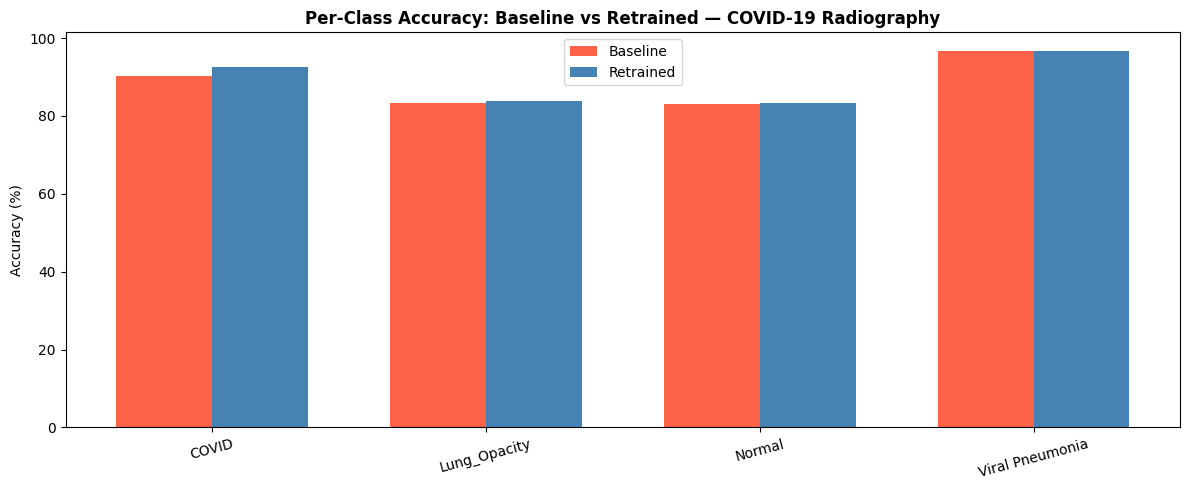

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

retrained_acc = evaluate_per_class(retrained_model, testloader)

print(f"\n{'Class':<22} {'Baseline':>10} {'Retrained':>10} {'Change':>10}")
print("=" * 55)
for i, cls in enumerate(CLASS_NAMES):
    b     = baseline_acc[i]
    r     = retrained_acc[i]
    delta = r - b
    flag  = ' ← WEAK (GAN augmented)' if i == WEAK_CLASS else ''
    print(f"{cls:<22} {b:>9.1f}% {r:>9.1f}% {delta:>+9.1f}%{flag}")
print("=" * 55)
b_mean = np.mean(list(baseline_acc.values()))
r_mean = np.mean(list(retrained_acc.values()))
print(f"{'Overall':<22} {b_mean:>9.1f}% {r_mean:>9.1f}% {r_mean-b_mean:>+9.1f}%")

# Bar chart
x, w = np.arange(4), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, [baseline_acc[i]  for i in range(4)],
       w, label='Baseline',  color='tomato')
ax.bar(x + w/2, [retrained_acc[i] for i in range(4)],
       w, label='Retrained', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy: Baseline vs Retrained — COVID-19 Radiography",
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

BASELINE:
                 precision    recall  f1-score   support

          COVID      0.844     0.903     0.872       723
   Lung_Opacity      0.820     0.835     0.827      1203
         Normal      0.904     0.831     0.866      2038
Viral Pneumonia      0.720     0.967     0.825       269

       accuracy                          0.853      4233
      macro avg      0.822     0.884     0.848      4233
   weighted avg      0.858     0.853     0.854      4233

RETRAINED:
                 precision    recall  f1-score   support

          COVID      0.824     0.927     0.872       723
   Lung_Opacity      0.813     0.840     0.826      1203
         Normal      0.915     0.834     0.873      2038
Viral Pneumonia      0.812     0.967     0.883       269

       accuracy                          0.860      4233
      macro avg      0.841     0.892     0.864      4233
   weighted avg      0.864     0.860     0.860      4233



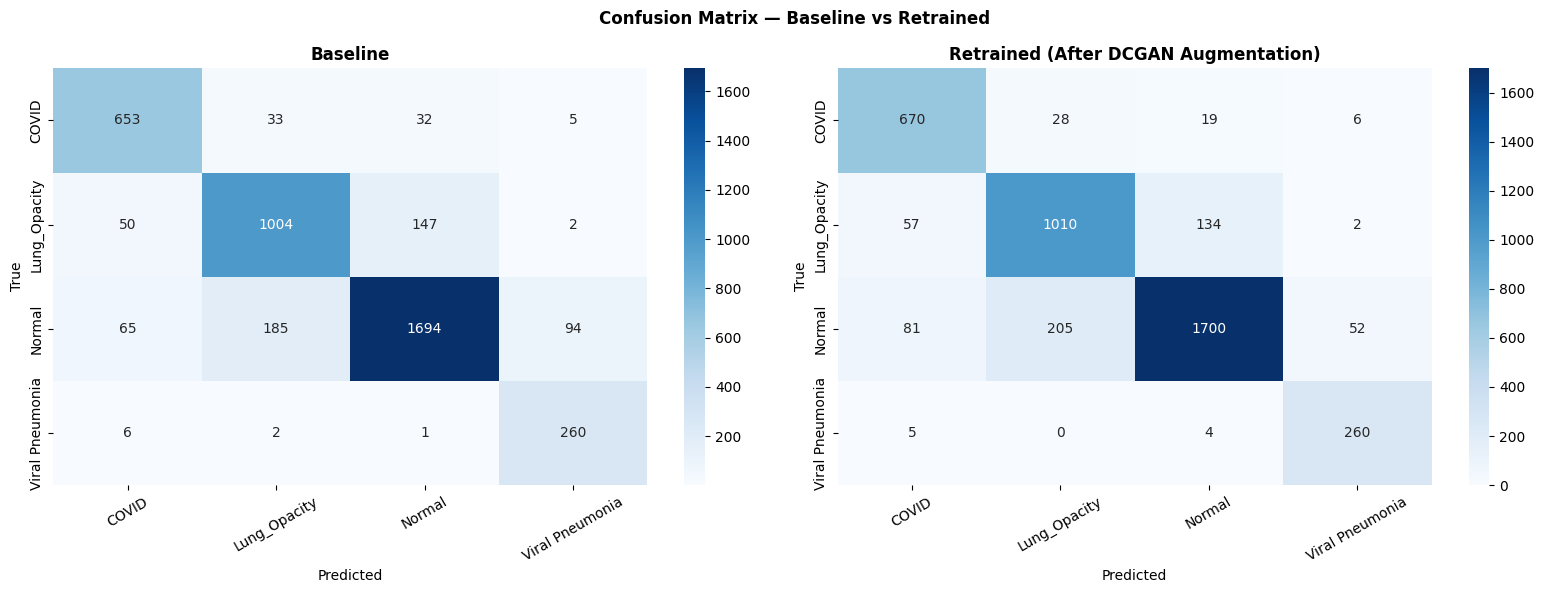

In [17]:
def get_preds(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            all_p.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            all_l.extend(lbls.numpy())
    return np.array(all_l), np.array(all_p)

true_labels, baseline_preds  = get_preds(baseline_model,  testloader)
true_labels, retrained_preds = get_preds(retrained_model, testloader)

print("BASELINE:")
print(classification_report(true_labels, baseline_preds,
                             target_names=CLASS_NAMES, digits=3))
print("RETRAINED:")
print(classification_report(true_labels, retrained_preds,
                             target_names=CLASS_NAMES, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, preds, title in zip(axes,
    [baseline_preds, retrained_preds],
    ["Baseline", "Retrained (After DCGAN Augmentation)"]):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Confusion Matrix — Baseline vs Retrained", fontweight='bold')
plt.tight_layout()
plt.show()